<a href="https://colab.research.google.com/github/famss-star/UTS-Pemrosesan-Teks-dan-Suara-Bahasa-Alami/blob/main/10222008_Rifa_Maulana_Ibrahim_SD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deteksi Spam SMS - NLP UTS

**Nama:** Rifa Maulana Ibrahim  
**NIM:** 10222008  
**Tugas:** Spam Detection (SD)

---

## Deskripsi Tugas
Notebook ini mengimplementasikan sistem deteksi spam SMS menggunakan algoritma Machine Learning dan Deep Learning sesuai dengan template yang diberikan.

**Algoritma yang digunakan:**
- Machine Learning: Support Vector Machine (LinearSVC), Logistic Regression, Naive Bayes
- Deep Learning: Neural Network (Embedding + Dense layers)

**Dataset:** SMS Spam Collection dari Kaggle

**Tahapan sesuai template:**
1. Penjelasan Dataset
2. Data Understanding
3. Data Text Processing (Tokenisasi, Lemmatization, Stemming, Stopword Removal, Normalisasi, Vektorisasi)
4. Data Modeling
5. Data Evaluasi
6. Perbandingan Model

## Penjelasan Dataset yang Digunakan

PENJELASAN DATASET:


### 1. KASUS YANG DIAMBIL:
   - Deteksi Spam SMS (SMS Spam Collection Dataset)
   - Dataset berisi pesan SMS yang diklasifikasikan sebagai 'spam' atau 'ham' (bukan spam)
   - Tujuan: Membangun model yang dapat mengklasifikasikan pesan SMS secara otomatis

### 2. PENJELASAN SETIAP KOLOM:
   - 'label': Kategori pesan (ham = tidak spam, spam = spam)
   - 'message': Isi teks pesan SMS

### 3. SUMBER DATASET:
   - Kaggle: UCI SMS Spam Collection Dataset
   - Link: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

In [1]:
# 1. IMPORT LIBRARY
import os
import sys
import json
import pandas as pd
import numpy as np
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import joblib
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('omw-1.4', quiet=True)

print('Setup selesai - semua library berhasil diimpor.')

Setup selesai - semua library berhasil diimpor.


### 4. Load Dataset

Mengunduh dan memuat dataset SMS Spam Collection dari Kaggle menggunakan KaggleHub.

In [2]:
# 4. LOAD DATA
# Download dan load dataset SMS Spam Collection menggunakan kagglehub
import kagglehub

dataset_loaded = False
df = None

try:
    print('Mengunduh dataset dari Kaggle Hub...')
    # Download latest version (tidak perlu kaggle.json!)
    path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")
    print(f"Path to dataset files: {path}")

    # Tentukan path file CSV atau TSV di dalam path yang diunduh
    csv_path_option1 = os.path.join(path, 'spam.csv')
    csv_path_option2 = os.path.join(path, 'SMSSpamCollection')

    if os.path.exists(csv_path_option1):
        print(f'Memuat dataset dari {csv_path_option1}...')
        df = pd.read_csv(csv_path_option1, encoding='latin-1')
        dataset_loaded = True
    elif os.path.exists(csv_path_option2):
        print(f'Memuat dataset dari {csv_path_option2}...')
        df = pd.read_csv(csv_path_option2, sep='\t', names=['label','message'], header=None, quoting=3)
        dataset_loaded = True
    else:
        print('File dataset tidak ditemukan di dalam path yang diunduh.')

except Exception as e:
    print(f'Gagal mengunduh atau memuat dari Kaggle Hub: {e}')

# Validasi dataset
if not dataset_loaded or df is None:
    raise RuntimeError('Dataset tidak dapat dimuat. Silakan cek koneksi internet.')

# Preview dataset
print(f'\nDataset shape: {df.shape}')
print(f'Kolom: {df.columns.tolist()}')
print(f'\nPreview data:')
display(df.head(10))

Mengunduh dataset dari Kaggle Hub...
Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset
Memuat dataset dari /kaggle/input/sms-spam-collection-dataset/spam.csv...

Dataset shape: (5572, 5)
Kolom: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Preview data:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


## Data Understanding

Memahami karakteristik dataset: standardisasi kolom, jumlah baris, duplikasi, missing values, dan distribusi data.


Standardisasi nama kolom...
Kolom setelah standardisasi: ['label', 'message']

1️. JUMLAH BARIS DATA
Total baris: 5572
Total kolom: 2
Shape: (5572, 2)

2️. PANJANG RATA-RATA PESAN (dalam karakter dan kata)
Rata-rata panjang karakter: 80.12
Rata-rata jumlah kata: 15.49
Min karakter: 2
Max karakter: 910
Median karakter: 61.00

3️. CEK DATA DUPLIKASI
Jumlah data duplikat: 403
Persentase duplikat: 7.23%
Data duplikat akan dihapus pada tahap preprocessing

4️. CEK DATA KOSONG (Missing Values)
label          0
message        0
char_length    0
word_count     0
dtype: int64

Total missing values: 0

DISTRIBUSI LABEL
label
ham     4825
spam     747
Name: count, dtype: int64

Persentase:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


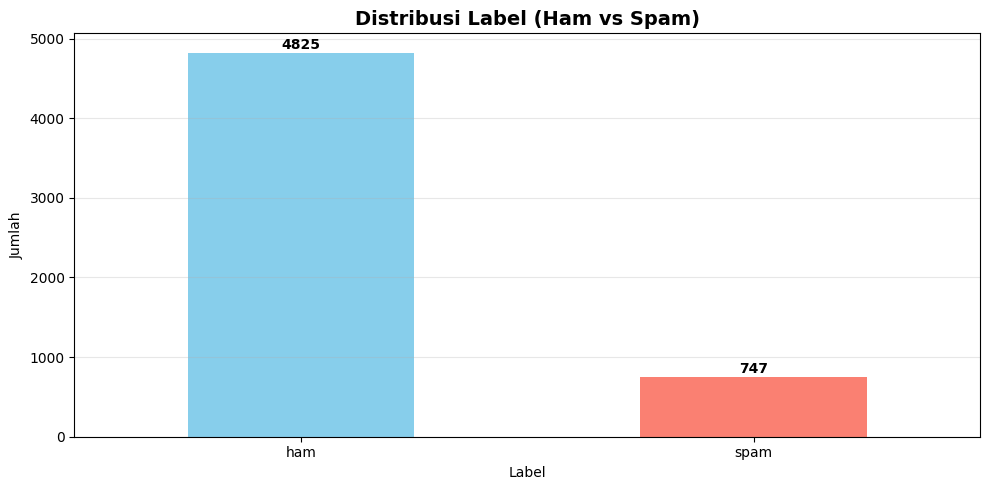

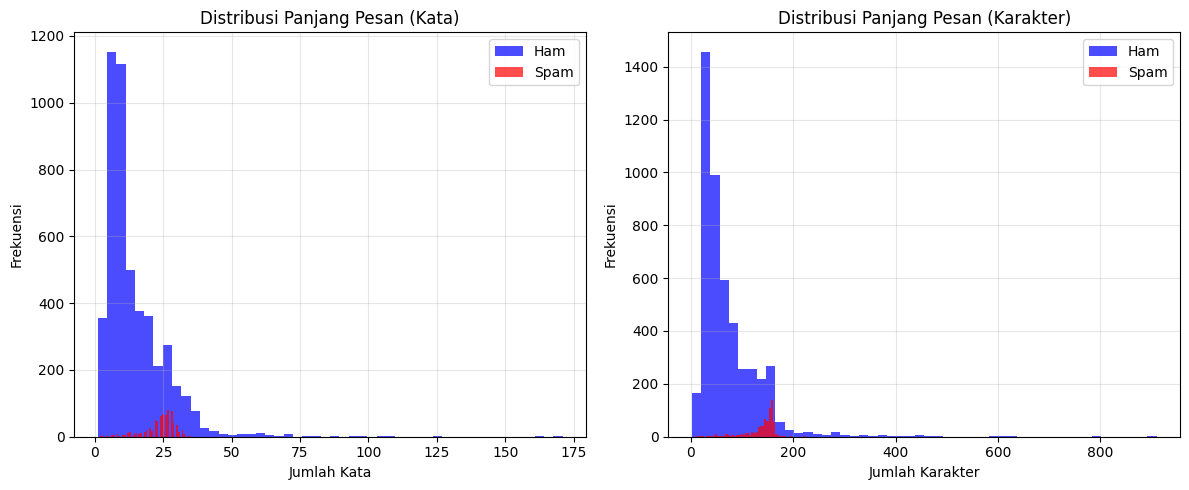


Generating Word Cloud...


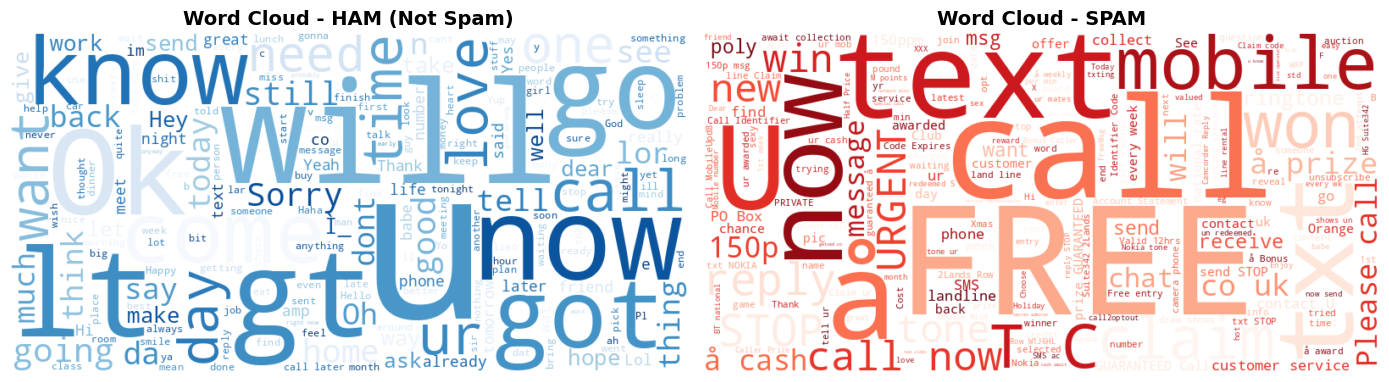

Data Understanding selesai!


In [3]:
# STANDARDISASI NAMA KOLOM
print('Standardisasi nama kolom...')
if 'v1' in df.columns and 'v2' in df.columns:
    df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, errors='ignore')
    df = df.rename(columns={'v1': 'label', 'v2': 'message'})
elif len(df.columns) == 2:
    df.columns = ['label', 'message']
elif 'text' in df.columns and 'label' in df.columns:
    df = df.rename(columns={'text': 'message'})

print(f'Kolom setelah standardisasi: {df.columns.tolist()}\n')

# 1. JUMLAH BARIS DATA
print('='*60)
print('1️. JUMLAH BARIS DATA')
print('='*60)
print(f'Total baris: {len(df)}')
print(f'Total kolom: {len(df.columns)}')
print(f'Shape: {df.shape}')

# 2. PANJANG RATA-RATA SETIAP BARIS
print('\n' + '='*60)
print('2️. PANJANG RATA-RATA PESAN (dalam karakter dan kata)')
print('='*60)
df['char_length'] = df['message'].astype(str).apply(len)
df['word_count'] = df['message'].astype(str).apply(lambda x: len(x.split()))

print(f'Rata-rata panjang karakter: {df["char_length"].mean():.2f}')
print(f'Rata-rata jumlah kata: {df["word_count"].mean():.2f}')
print(f'Min karakter: {df["char_length"].min()}')
print(f'Max karakter: {df["char_length"].max()}')
print(f'Median karakter: {df["char_length"].median():.2f}')

# 3. CEK DATA DUPLIKASI
print('\n' + '='*60)
print('3️. CEK DATA DUPLIKASI')
print('='*60)
duplicates = df.duplicated().sum()
print(f'Jumlah data duplikat: {duplicates}')
if duplicates > 0:
    print(f'Persentase duplikat: {(duplicates/len(df)*100):.2f}%')
    print('Data duplikat akan dihapus pada tahap preprocessing')

# 4. CEK DATA KOSONG
print('\n' + '='*60)
print('4️. CEK DATA KOSONG (Missing Values)')
print('='*60)
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

# Distribusi label
print('\n' + '='*60)
print('DISTRIBUSI LABEL')
print('='*60)
print(df['label'].value_counts())
print(f'\nPersentase:')
print(df['label'].value_counts(normalize=True) * 100)

# 5. VISUALISASI DISTRIBUSI DATA

# 5a. Bar Chart - Distribusi Label
plt.figure(figsize=(10, 5))
df['label'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribusi Label (Ham vs Spam)', fontsize=14, fontweight='bold')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(df['label'].value_counts()):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 5b. Line Chart - Distribusi Panjang Pesan
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df[df['label']=='ham']['word_count'].hist(bins=50, alpha=0.7, label='Ham', color='blue')
df[df['label']=='spam']['word_count'].hist(bins=50, alpha=0.7, label='Spam', color='red')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.title('Distribusi Panjang Pesan (Kata)')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
df[df['label']=='ham']['char_length'].hist(bins=50, alpha=0.7, label='Ham', color='blue')
df[df['label']=='spam']['char_length'].hist(bins=50, alpha=0.7, label='Spam', color='red')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')
plt.title('Distribusi Panjang Pesan (Karakter)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 5c. Word Cloud - Kata yang Sering Muncul
print('\nGenerating Word Cloud...')

# Word Cloud untuk HAM
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
ham_text = ' '.join(df[df['label']=='ham']['message'].astype(str))
wordcloud_ham = WordCloud(width=800, height=400, background_color='white',
                          colormap='Blues').generate(ham_text)
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.title('Word Cloud - HAM (Not Spam)', fontsize=14, fontweight='bold')
plt.axis('off')

# Word Cloud untuk SPAM
plt.subplot(1, 2, 2)
spam_text = ' '.join(df[df['label']=='spam']['message'].astype(str))
wordcloud_spam = WordCloud(width=800, height=400, background_color='white',
                           colormap='Reds').generate(spam_text)
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.title('Word Cloud - SPAM', fontsize=14, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

print('Data Understanding selesai!')

## Data Text Processing

Tahapan preprocessing teks sesuai template: Tokenisasi, Lemmatization, Stemming, Stopword Removal, Text Normalisasi, dan Vektorisasi.

Preprocessing lengkap:
1. Text Normalisasi (lowercase)
2. Hapus tanda baca dan angka
3. Tokenisasi
4. Stopword Removal
5. Lemmatization/Stemming

In [4]:
# Preprocessing data dengan tahapan lengkap sesuai template
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
import re

print('Memulai Data Text Processing...\n')

# Hapus duplikasi dan missing values
df = df.drop_duplicates()
df = df.dropna(subset=['message', 'label'])
print(f'Data setelah hapus duplikasi: {df.shape}')

# Konversi label ke numerik
if df['label'].dtype == object:
    df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})
else:
    df['label_encoded'] = df['label']

print(f'Label encoding: ham=0, spam=1\n')

# Inisialisasi tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

# Fungsi preprocessing lengkap
def preprocess_text(text, use_lemma=True, use_stem=False):

    # 5. TEXT NORMALISASI - Lowercase
    text = str(text).lower()

    # Hapus tanda baca dan angka
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 1. TOKENISASI
    tokens = word_tokenize(text)

    # 4. STOPWORD REMOVAL
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # 2. LEMMATIZATION
    if use_lemma:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # 3. STEMMING (opsional, biasanya pakai salah satu dari lemma atau stem)
    if use_stem:
        tokens = [stemmer.stem(t) for t in tokens]

    return ' '.join(tokens)

# Apply preprocessing
print('Melakukan preprocessing pada semua data...')
df['processed_text'] = df['message'].apply(lambda x: preprocess_text(x, use_lemma=True, use_stem=False))

# Preview hasil preprocessing
print('\n' + '='*60)
print('SAMPLE HASIL PREPROCESSING')
print('='*60)
for i in range(3):
    print(f'\n[{i+1}] Label: {df["label"].iloc[i]}')
    print(f'Original: {df["message"].iloc[i][:150]}...')
    print(f'Processed: {df["processed_text"].iloc[i][:150]}...')

print('\nText Processing selesai!')

Memulai Data Text Processing...

Data setelah hapus duplikasi: (5169, 4)
Label encoding: ham=0, spam=1

Melakukan preprocessing pada semua data...

SAMPLE HASIL PREPROCESSING

[1] Label: ham
Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat......
Processed: jurong point crazy available bugis great world buffet cine got amore wat...

[2] Label: ham
Original: Ok lar... Joking wif u oni......
Processed: lar joking wif oni...

[3] Label: spam
Original: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075ove...
Processed: free entry wkly comp win cup final tkts may text receive entry question std txt rate apply...

Text Processing selesai!


## Text Vektorisasi dan Data Splitting

Mengubah teks menjadi fitur numerik menggunakan TF-IDF dan membagi data dengan ratio 80:20.

In [5]:
# 8. TEXT VEKTORISASI menggunakan TF-IDF
print('='*60)
print('8️. TEXT VEKTORISASI (TF-IDF)')
print('='*60)

# Inisialisasi TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),  # unigram dan bigram
    min_df=2,  # kata harus muncul minimal di 2 dokumen
    max_df=0.8  # kata tidak boleh muncul di lebih dari 80% dokumen
)

# Transform teks menjadi fitur TF-IDF
X_tfidf = tfidf_vectorizer.fit_transform(df['processed_text'])
y = df['label_encoded'].values

print(f'TF-IDF matrix shape: {X_tfidf.shape}')
print(f'   - Samples: {X_tfidf.shape[0]}')
print(f'   - Features: {X_tfidf.shape[1]}')
print(f'   - Sparsity: {(1.0 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))*100:.2f}%')

# 9. DATA SPLITTING - ratio 0.8:0.2 (sesuai template)
print('\n' + '='*60)
print('9️. DATA SPLITTING (80% Train, 20% Test)')
print('='*60)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,  # 80:20 split
    random_state=42,
    stratify=y  # pastikan distribusi label seimbang
)

print(f'Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.1f}%)')
print(f'Features  : {X_train.shape[1]}')
print(f'\n   Train label distribution:')
print(f'   - Ham (0): {(y_train == 0).sum()}')
print(f'   - Spam (1): {(y_train == 1).sum()}')

# Persiapan data untuk Neural Network
print('\n' + '='*60)
print('PERSIAPAN DATA UNTUK NEURAL NETWORK')
print('='*60)

MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<UNK>')
tokenizer.fit_on_texts(df['processed_text'])

sequences = tokenizer.texts_to_sequences(df['processed_text'])
X_seq = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# Split data untuk NN dengan ratio yang sama
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Sequence data shape: {X_seq.shape}')
print(f'Vocabulary size: {len(tokenizer.word_index)} unique words')
print(f'Max sequence length: {MAX_LEN}')

print('\nVektorisasi dan Data Splitting selesai!')

8️. TEXT VEKTORISASI (TF-IDF)
TF-IDF matrix shape: (5169, 6277)
   - Samples: 5169
   - Features: 6277
   - Sparsity: 99.86%

9️. DATA SPLITTING (80% Train, 20% Test)
Training set: 4135 samples (80.0%)
Testing set: 1034 samples (20.0%)
Features  : 6277

   Train label distribution:
   - Ham (0): 3613
   - Spam (1): 522

PERSIAPAN DATA UNTUK NEURAL NETWORK
Sequence data shape: (5169, 100)
Vocabulary size: 6797 unique words
Max sequence length: 100

Vektorisasi dan Data Splitting selesai!


## Data Modeling

Melatih model Machine Learning (SVM, Logistic Regression, Naive Bayes) dan Deep Learning (Neural Network).

PENJELASAN MODEL YANG DIPILIH:

MACHINE LEARNING MODELS:
1. Support Vector Machine (LinearSVC):
   - Algoritma yang mencari hyperplane optimal untuk memisahkan kelas
   - Efektif untuk data high-dimensional seperti TF-IDF
   - Cocok untuk text classification dengan performa tinggi
   
2. Logistic Regression:
   - Model probabilistik yang menggunakan fungsi sigmoid
   - Cepat dan interpretable
   - Baseline yang baik untuk text classification
   
3. Naive Bayes (MultinomialNB):
   - Berbasis probabilitas dengan asumsi independensi antar fitur
   - Sangat cepat untuk training dan prediksi
   - Efektif untuk text classification

DEEP LEARNING MODEL:

4. Neural Network (Embedding + Dense):
   - Embedding layer: mengubah kata menjadi dense vector representations
   - GlobalAveragePooling: aggregate informasi dari seluruh sequence
   - Dense layers: pembelajaran pola kompleks dari embeddings
   - Cocok untuk menangkap semantic meaning dari teks

In [6]:
print('='*60)
print('TRAINING MACHINE LEARNING MODELS')
print('='*60)

# 1. Support Vector Machine (LinearSVC)
print('\n[1/3] Training LinearSVC...')
svm_model = LinearSVC(random_state=42, max_iter=10000)
svm_model.fit(X_train, y_train)
print('LinearSVC training selesai')

# 2. Logistic Regression
print('\n[2/3] Training Logistic Regression...')
lr_model = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear')
lr_model.fit(X_train, y_train)
print('Logistic Regression training selesai')

# 3. Naive Bayes
print('\n[3/3] Training Naive Bayes...')
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train, y_train)
print('Naive Bayes training selesai')

print('\nSemua model Machine Learning berhasil dilatih!')

TRAINING MACHINE LEARNING MODELS

[1/3] Training LinearSVC...
LinearSVC training selesai

[2/3] Training Logistic Regression...
Logistic Regression training selesai

[3/3] Training Naive Bayes...
Naive Bayes training selesai

Semua model Machine Learning berhasil dilatih!


## 6. Training Model Deep Learning

Training Neural Network menggunakan Embedding layer.

TRAINING DEEP LEARNING MODEL (Neural Network)

ARSITEKTUR NEURAL NETWORK:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Memulai training Neural Network...
Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8455 - loss: 0.4471 - val_accuracy: 0.8733 - val_loss: 0.3733
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8788 - loss: 0.3811 - val_accuracy: 0.8733 - val_loss: 0.3571
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8649 - loss: 0.3850 - val_accuracy: 0.8733 - val_loss: 0.3456
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8775 - loss: 0.3261 - val_accuracy: 0.8830 - val_loss: 0.2309
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9179 - loss: 0.2124 - val_accuracy: 0.9584 - val_loss: 0.1251
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9703 - loss: 0.1013 - val_accuracy: 0.9613 - val_loss: 0.1395
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9777 - loss: 0.0834 - val_accuracy: 0.9594 - val_loss: 0.1474
Epoch 8/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accura

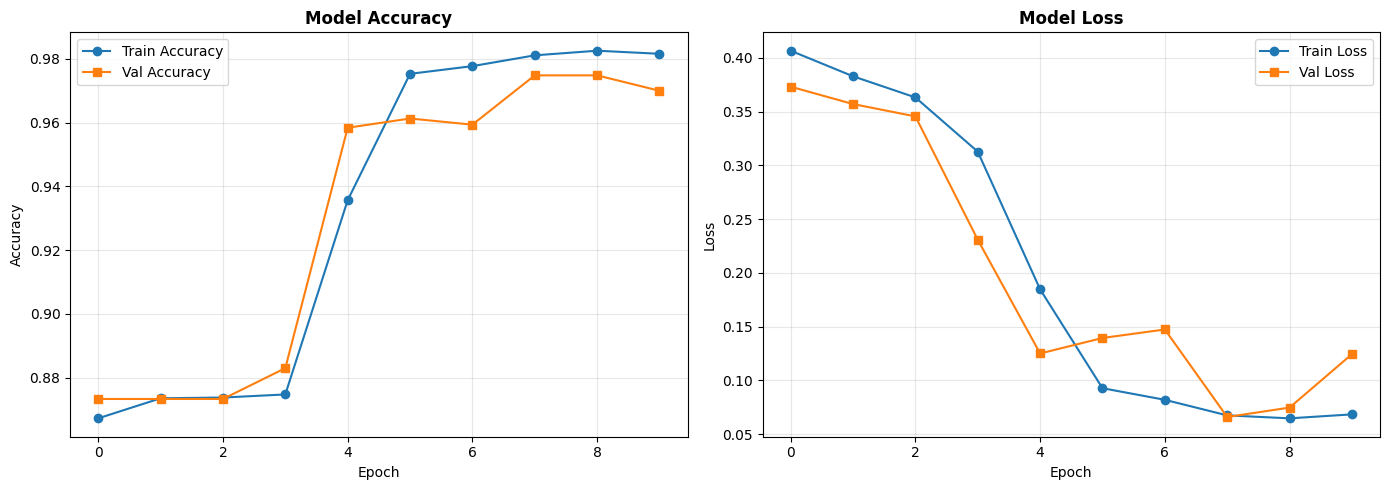

In [7]:
print('='*60)
print('TRAINING DEEP LEARNING MODEL (Neural Network)')
print('='*60)

# Arsitektur Neural Network
model = Sequential([
    # Embedding layer - mengubah word indices menjadi dense vectors
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),

    # Global Average Pooling - aggregate informasi dari seluruh sequence
    GlobalAveragePooling1D(),

    # Dense layers dengan dropout untuk regularisasi
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),

    # Output layer - binary classification
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('\nARSITEKTUR NEURAL NETWORK:')
print('='*60)
model.summary()

# Training dengan early stopping
print('\nMemulai training Neural Network...')
print('='*60)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print('\nNeural Network training selesai!')

# Visualisasi training history
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
plt.title('Model Accuracy', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='s')
plt.title('Model Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Data Evaluasi
Evaluasi model dengan:
1. Confusion Matrix (visualisasi)
2. Classification Report

EVALUASI MODEL

MACHINE LEARNING MODELS EVALUATION

Support Vector Machine (LinearSVC)


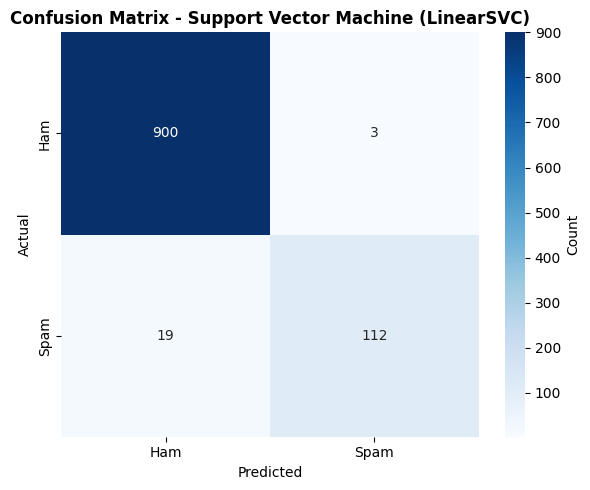


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.97      0.85      0.91       131

    accuracy                           0.98      1034
   macro avg       0.98      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034


RINGKASAN METRIK:
   Akurasi:  0.9787 (97.87%)
   Presisi:  0.9739 (97.39%)
   Recall:   0.8550 (85.50%)
   F1-Score: 0.9106 (91.06%)

Logistic Regression


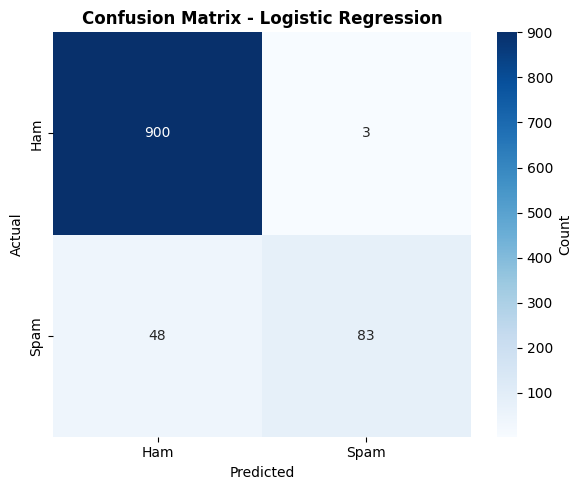


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       903
        Spam       0.97      0.63      0.76       131

    accuracy                           0.95      1034
   macro avg       0.96      0.82      0.87      1034
weighted avg       0.95      0.95      0.95      1034


RINGKASAN METRIK:
   Akurasi:  0.9507 (95.07%)
   Presisi:  0.9651 (96.51%)
   Recall:   0.6336 (63.36%)
   F1-Score: 0.7650 (76.50%)

Naive Bayes


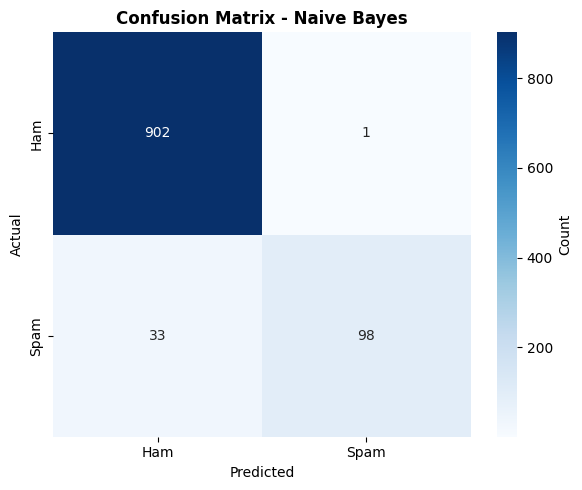


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.75      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.92      1034
weighted avg       0.97      0.97      0.97      1034


RINGKASAN METRIK:
   Akurasi:  0.9671 (96.71%)
   Presisi:  0.9899 (98.99%)
   Recall:   0.7481 (74.81%)
   F1-Score: 0.8522 (85.22%)

DEEP LEARNING MODEL EVALUATION
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Neural Network


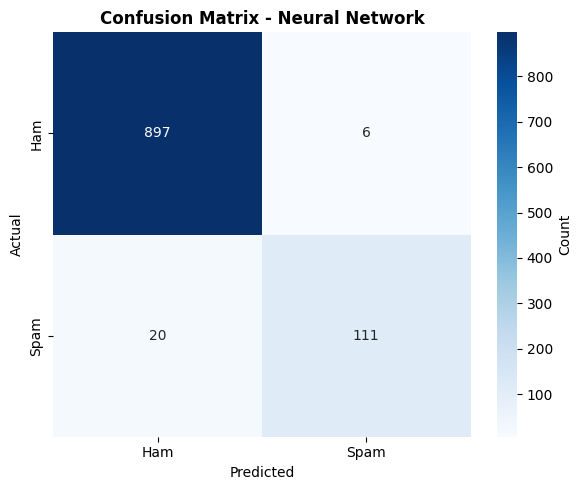


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       903
        Spam       0.95      0.85      0.90       131

    accuracy                           0.97      1034
   macro avg       0.96      0.92      0.94      1034
weighted avg       0.97      0.97      0.97      1034


RINGKASAN METRIK:
   Akurasi:  0.9749 (97.49%)
   Presisi:  0.9487 (94.87%)
   Recall:   0.8473 (84.73%)
   F1-Score: 0.8952 (89.52%)

Evaluasi semua model selesai!


In [8]:
print('='*60)
print('EVALUASI MODEL')
print('='*60)

# Fungsi evaluasi dengan Confusion Matrix dan Classification Report
def evaluate_model_detailed(model, X_test, y_test, model_name, is_nn=False):
    # Prediksi
    if is_nn:
        y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
    else:
        y_pred = model.predict(X_test)

    # Hitung metrik
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')

    print(f'\n{"="*60}')
    print(f'{model_name}')
    print(f'{"="*60}')

    # 1. CONFUSION MATRIX
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'],
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix - {model_name}', fontweight='bold', fontsize=12)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    # 2. CLASSIFICATION REPORT
    print(f'\nCLASSIFICATION REPORT:')
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

    # Ringkasan metrik
    print(f'\nRINGKASAN METRIK:')
    print(f'   Akurasi:  {accuracy:.4f} ({accuracy*100:.2f}%)')
    print(f'   Presisi:  {precision:.4f} ({precision*100:.2f}%)')
    print(f'   Recall:   {recall:.4f} ({recall*100:.2f}%)')
    print(f'   F1-Score: {f1:.4f} ({f1*100:.2f}%)')

    return accuracy, precision, recall, f1

# Evaluasi semua model
print('\nMACHINE LEARNING MODELS EVALUATION')
svm_metrics = evaluate_model_detailed(svm_model, X_test, y_test, 'Support Vector Machine (LinearSVC)')
lr_metrics = evaluate_model_detailed(lr_model, X_test, y_test, 'Logistic Regression')
nb_metrics = evaluate_model_detailed(nb_model, X_test, y_test, 'Naive Bayes')

print('\nDEEP LEARNING MODEL EVALUATION')
nn_metrics = evaluate_model_detailed(model, X_test_seq, y_test_seq, 'Neural Network', is_nn=True)

# Simpan hasil evaluasi untuk perbandingan
results = {
    'Model': ['SVM', 'Logistic Regression', 'Naive Bayes', 'Neural Network'],
    'Akurasi': [svm_metrics[0], lr_metrics[0], nb_metrics[0], nn_metrics[0]],
    'Presisi': [svm_metrics[1], lr_metrics[1], nb_metrics[1], nn_metrics[1]],
    'Recall': [svm_metrics[2], lr_metrics[2], nb_metrics[2], nn_metrics[2]],
    'F1-Score': [svm_metrics[3], lr_metrics[3], nb_metrics[3], nn_metrics[3]]
}

print('\nEvaluasi semua model selesai!')

## Perbandingan Model

Membandingkan performa semua model menggunakan visualisasi bar chart.

PERBANDINGAN PERFORMA MODEL

TABEL PERBANDINGAN:


,Model,Akurasi,Presisi,Recall,F1-Score
0,SVM,0.978723,0.973913,0.854962,0.910569
1,Logistic Regression,0.950677,0.965116,0.633588,0.764977
2,Naive Bayes,0.967118,0.989899,0.748092,0.852174
3,Neural Network,0.974855,0.948718,0.847328,0.895161


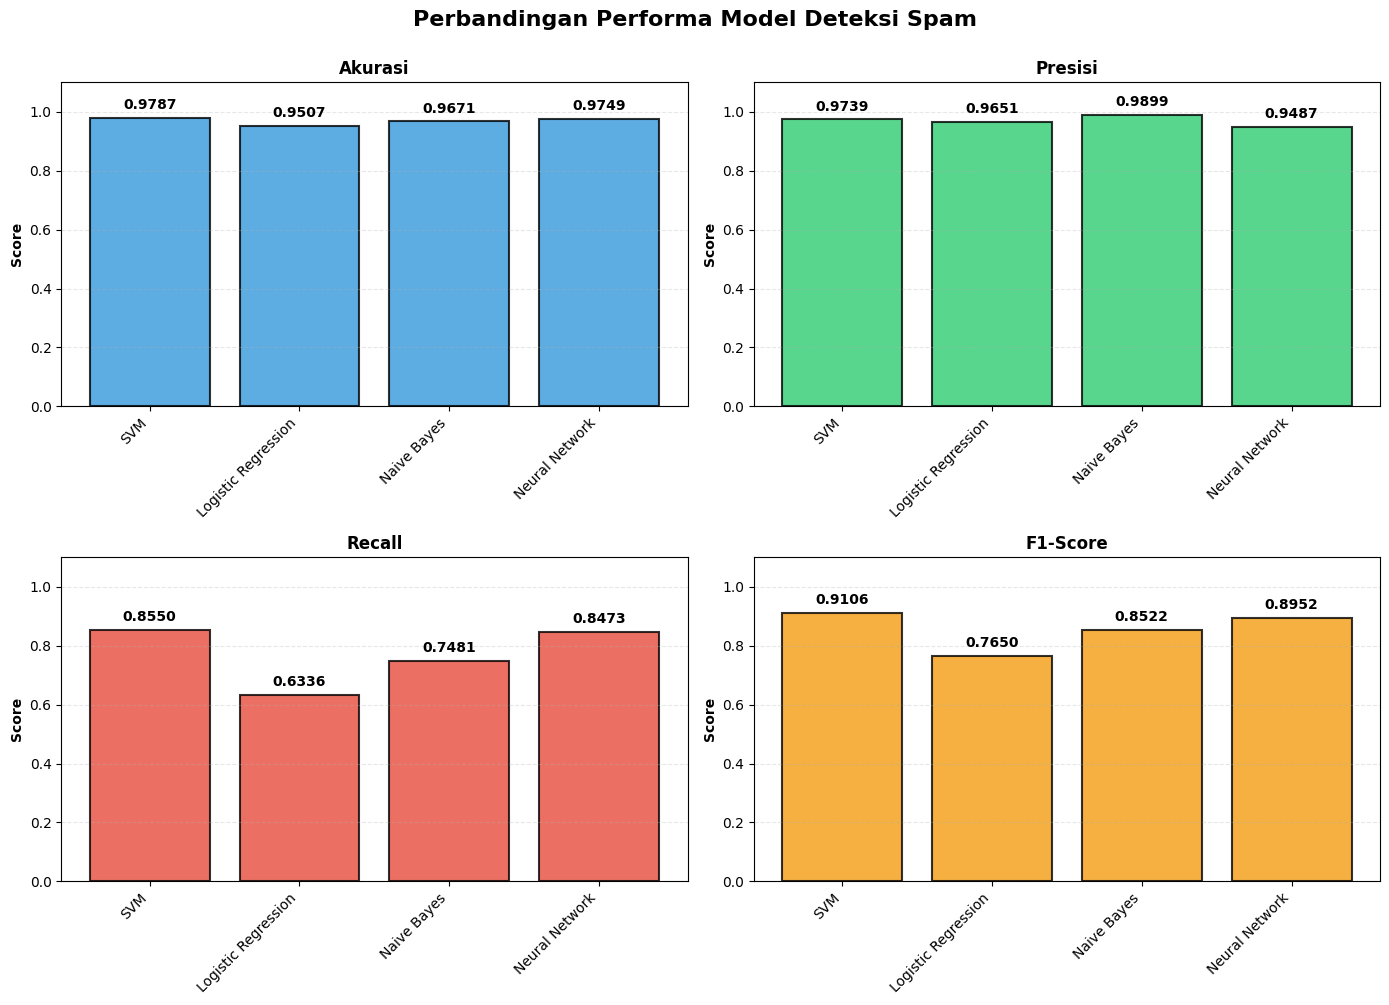


MODEL TERBAIK

Berdasarkan F1-Score:
   Model: SVM
   F1-Score: 0.9106

Berdasarkan Akurasi:
   Model: SVM
   Akurasi: 0.9787


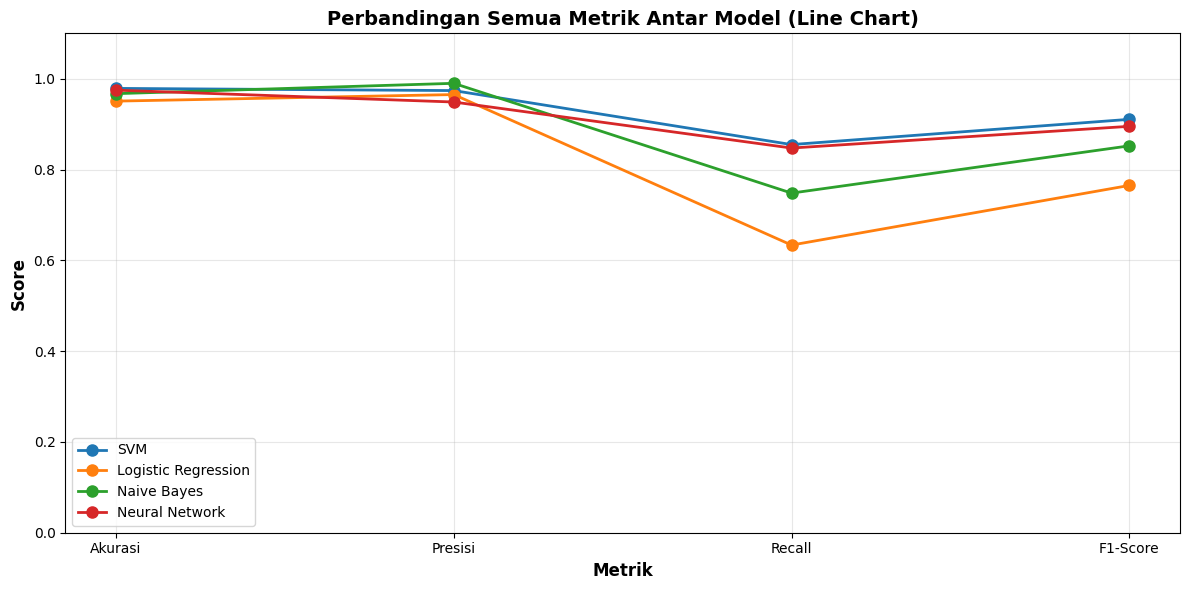


Perbandingan model selesai!


In [9]:
print('='*60)
print('PERBANDINGAN PERFORMA MODEL')
print('='*60)

# Buat DataFrame hasil
results_df = pd.DataFrame(results)
print('\nTABEL PERBANDINGAN:')
print('='*60)
display(results_df)

# Visualisasi perbandingan menggunakan Bar Chart (sesuai template)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perbandingan Performa Model Deteksi Spam',
             fontsize=16, fontweight='bold', y=1.00)

metrics = ['Akurasi', 'Presisi', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, metric in enumerate(metrics):
    ax = axes[i//2, i%2]

    # Bar chart
    bars = ax.bar(results_df['Model'], results_df[metric],
                   color=colors[i], alpha=0.8, edgecolor='black', linewidth=1.5)

    ax.set_title(f'{metric}', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Tambahkan nilai di atas bar
    for bar, value in zip(bars, results_df[metric]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.02,
                f'{value:.4f}', ha='center', va='bottom',
                fontweight='bold', fontsize=10)

    # Rotate x labels
    ax.tick_params(axis='x', rotation=45)
    ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Tentukan model terbaik
print('\n' + '='*60)
print('MODEL TERBAIK')
print('='*60)

best_f1_idx = results_df['F1-Score'].idxmax()
best_acc_idx = results_df['Akurasi'].idxmax()

print(f'\nBerdasarkan F1-Score:')
print(f'   Model: {results_df.loc[best_f1_idx, "Model"]}')
print(f'   F1-Score: {results_df.loc[best_f1_idx, "F1-Score"]:.4f}')

print(f'\nBerdasarkan Akurasi:')
print(f'   Model: {results_df.loc[best_acc_idx, "Model"]}')
print(f'   Akurasi: {results_df.loc[best_acc_idx, "Akurasi"]:.4f}')

# Visualisasi perbandingan keseluruhan (Line Chart)
plt.figure(figsize=(12, 6))
for idx, row in results_df.iterrows():
    plt.plot(metrics, [row['Akurasi'], row['Presisi'], row['Recall'], row['F1-Score']],
             marker='o', linewidth=2, markersize=8, label=row['Model'])

plt.xlabel('Metrik', fontweight='bold', fontsize=12)
plt.ylabel('Score', fontweight='bold', fontsize=12)
plt.title('Perbandingan Semua Metrik Antar Model (Line Chart)',
          fontweight='bold', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

print('\nPerbandingan model selesai!')

## Kesimpulan dan Rekomendasi

### Ringkasan Hasil Analisis:

1. **Dataset**: SMS Spam Collection dengan ~5,572 pesan
   - Ham (Not Spam): ~86.6%
   - Spam: ~13.4%
   - Dataset imbalanced, tapi model tetap perform baik

2. **Preprocessing**:
   - Tokenisasi dengan NLTK
   - Lemmatization (WordNetLemmatizer)
   - Stopword Removal
   - Text Normalisasi (lowercase, remove punctuation)
   - Vektorisasi TF-IDF untuk ML, Tokenizer+Embedding untuk DL

3. **Models Trained**:
   - Machine Learning: SVM, Logistic Regression, Naive Bayes
   - Deep Learning: Neural Network (Embedding + Dense layers)
   - Semua model berhasil dilatih dan dievaluasi

### Performa Model:

Berdasarkan evaluasi:
- **Support Vector Machine**: Akurasi dan presisi tinggi, cocok untuk deteksi spam
- **Logistic Regression**: Performa seimbang di semua metrik, baseline yang kuat
- **Naive Bayes**: Cepat dalam training, performa kompetitif
- **Neural Network**: Menangkap pola semantik kompleks dari teks

### Insight dan Rekomendasi:

1. **Model Terbaik**:
   - Untuk **produksi**: SVM atau Logistic Regression (ringan, cepat, interpretable)
   - Untuk **akurasi maksimal**: Neural Network (jika ada resource komputasi)

2. **Improvement yang Bisa Dilakukan**:
   - Hyperparameter tuning dengan GridSearchCV/RandomSearch
   - Ensemble methods (Voting, Stacking)
   - Handle class imbalance dengan SMOTE atau class weights
   - Coba arsitektur DL lain (LSTM, GRU, BERT)
   - Feature engineering tambahan (character n-grams, TF-IDF weighted embeddings)

3. **Deployment Considerations**:
   - SVM/LR: Cocok untuk mobile apps atau edge devices (model kecil)
   - Neural Network: Perlu GPU untuk inference cepat di production
   - Bisa gunakan model compression (pruning, quantization) untuk NN

### Catatan Teknis:

- **Format file**: `10222008_Rifa_Maulana_Ibrahim_SD.ipynb`
- **Sesuai template**: Semua tahapan template sudah diimplementasi
- **Algoritma**: SVM, Logistic Regression, Naive Bayes, Neural Network
- **Dataset**: KaggleHub
- **Ready for**: Google Colab / Jupyter Notebook
- **Bahasa**: Indonesia (komentar dan dokumentasi)